<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/ML_In_Chem/Wine_class_1077167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **WINE QUALITY CLASSIFICATION** - Kwanda Mazibuko stdnr : 1077167

<div style="text-align: center;">
   <img src="https://www.coravin.com/cdn/shop/articles/AdobeStock_451146882_96704b3a-4335-4aea-927b-b79404ca7ba0.jpg?v=1755930405" >
</div>


# **Importing Libraries**

In [ ]:
!pip install plotly
!pip install missingno
!pip install scikit-learn
!pip install tabulate
!pip install pandas openpyxl

In [ ]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Feature engineering, selection and Model training
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    recall_score, precision_score, roc_curve, roc_auc_score, RocCurveDisplay
)


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Data acquisition**

In [ ]:
# Reading data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/ML_In_Chem/wine.csv"
df = pd.read_csv(url)
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# **Data Preprocessing**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



#### Reviewing and Renaming Columns


In [ ]:
# data columns
df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

- There are column names that have 'dots' as separators. These 'dots' are  replaced with an 'underscore' to prevent syntax errors since 'dots' have a different meaning in pandas dataframes. Also, all variable names are converted to lowercase.

In [ ]:
# Changing column names
df.columns = df.columns.str.replace('.', '_', regex=False).str.lower()
df.columns

Index(['wine', 'alcohol', 'malic_acid', 'ash', 'acl', 'mg', 'phenols',
       'flavanoids', 'nonflavanoid_phenols', 'proanth', 'color_int', 'hue',
       'od', 'proline'],
      dtype='object')

- since *wine* is the target variable, it is often good practice to have it at the end of dataframe.

In [ ]:
# swapping columns
df = df[['alcohol', 'malic_acid', 'ash', 'acl', 'mg', 'phenols',
       'flavanoids', 'nonflavanoid_phenols', 'proanth', 'color_int', 'hue',
       'od', 'proline','wine']]
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'acl', 'mg', 'phenols', 'flavanoids',
       'nonflavanoid_phenols', 'proanth', 'color_int', 'hue', 'od', 'proline',
       'wine'],
      dtype='object')

#### Dataset Dimensions and Variable Type

In [ ]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables:')
print('')
for i in df.columns:
  missing_values = 100*df[i].isnull().sum()/df.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))
  print('')

Data has 178 rows and 14 Columns

Data has the following variables:

wine, with 0.0% of missing data

alcohol, with 0.0% of missing data

malic_acid, with 0.0% of missing data

ash, with 0.0% of missing data

acl, with 0.0% of missing data

mg, with 0.0% of missing data

phenols, with 0.0% of missing data

flavanoids, with 0.0% of missing data

nonflavanoid_phenols, with 0.0% of missing data

proanth, with 0.0% of missing data

color_int, with 0.0% of missing data

hue, with 0.0% of missing data

od, with 0.0% of missing data

proline, with 0.0% of missing data



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wine                  178 non-null    int64  
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   acl                   178 non-null    float64
 5   mg                    178 non-null    int64  
 6   phenols               178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanth               178 non-null    float64
 10  color_int             178 non-null    float64
 11  hue                   178 non-null    float64
 12  od                    178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


- Dataset has no missing values and all the datatypes are numeric, which is crucial for building models. This means that no data imputation is required and no encoding is required since there are no categorical variables.

#### Summary Statistics and Variable Description

In [ ]:
#describing numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [ ]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "alcohol", "description": "Ethanol content in the wine (%). Higher values often correlate with stronger wines."},
    {"variable": "malic_acid", "description": "Amount of malic acid, which contributes to the tart taste of wine."},
    {"variable": "ash", "description": "Total ash content, representing mineral content after combustion."},
    {"variable": "acl", "description": "Measures the buffering capacity of ash, related to the wine’s pH stability."},
    {"variable": "mg", "description": "Magnesium concentration, a mineral that can influence taste and fermentation."},
    {"variable": "phenols", "description": "Sum of all phenolic compounds, which affect taste, color, and antioxidant properties."},
    {"variable": "flavanoids", "description": "Subclass of phenols known for their antioxidant effects and contribution to bitterness."},
    {"variable": "nonflavanoid_phenols", "description": "Phenolic compounds not classified as flavanoids, also influencing taste"},
    {"variable": "proanth", "description": "Type of tannin contributing to astringency and color stability."},
    {"variable": "color_int", "description": "Measurement of wine color depth, often linked to grape variety and aging."},
    {"variable": "hue", "description": "Ratio of absorbance at 520 nm to 420 nm, indicating wine color tone (red vs. brown)."},
    {"variable": "od", "description": "Optical density ratio used to estimate wine quality and phenolic content."},
    {"variable": "proline", "description": "Amino acid concentration, often higher in quality wines due to fermentation processes."},
    {"variable": "Wine", "description": "Wine quality."}
]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))


+----+----------------------+-----------------------------------------------------------------------------------------+
|    | variable             | description                                                                             |
+====+======================+=========================================================================================+
|  0 | alcohol              | Ethanol content in the wine (%). Higher values often correlate with stronger wines.     |
+----+----------------------+-----------------------------------------------------------------------------------------+
|  1 | malic_acid           | Amount of malic acid, which contributes to the tart taste of wine.                      |
+----+----------------------+-----------------------------------------------------------------------------------------+
|  2 | ash                  | Total ash content, representing mineral content after combustion.                       |
+----+----------------------+-----------

# **Feature Engineering**

This is a vital step where data is explored and then transformed from raw data into features that enhance machine learning model performance, accuracy, and generalization by making patterns more discernable.

### **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

#### **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

In [ ]:
df.head()

,alcohol,malic_acid,ash,acl,mg,phenols,flavanoids,nonflavanoid_phenols,proanth,color_int,hue,od,proline,wine
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


#### Wine Class Distribution

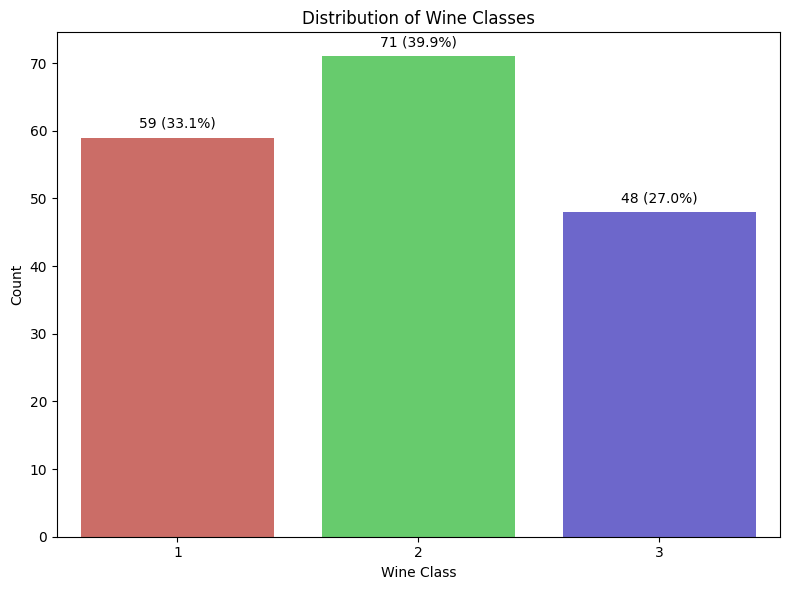

In [ ]:
df_1 = df.copy()
total = len(df_1)

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='wine', data=df_1, palette='hls')
plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Count")

# Add count and percentage labels
for p in ax.patches:
    count = int(p.get_height())
    percent = f"{100 * count / total:.1f}%"
    label = f"{count} ({percent})"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(x, y + 1, label, ha = "center", va = "bottom", fontsize = 10)

plt.tight_layout()
plt.show()

- These classes are fairly balanced, reflecting the real-world frequency of each wine class. Balancing them (either by oversampling or undersampling) would introduce bias or noise, potentially leading to unrealistic predictions. For an example in wine classification, if high-quality wines are rare, a balanced model might overestimate their likelihood, leading to unrealistic predictions in production.
- Undersampling, which removes instances from the majority class, results in a loss of potentially valuable information that could have improved the model.

- It is often good practice to balance classes whenever one is greater than  90% or one is less than 10%  of the data. But this is not the case in this data.


#### **Predictor Variables Distribution**

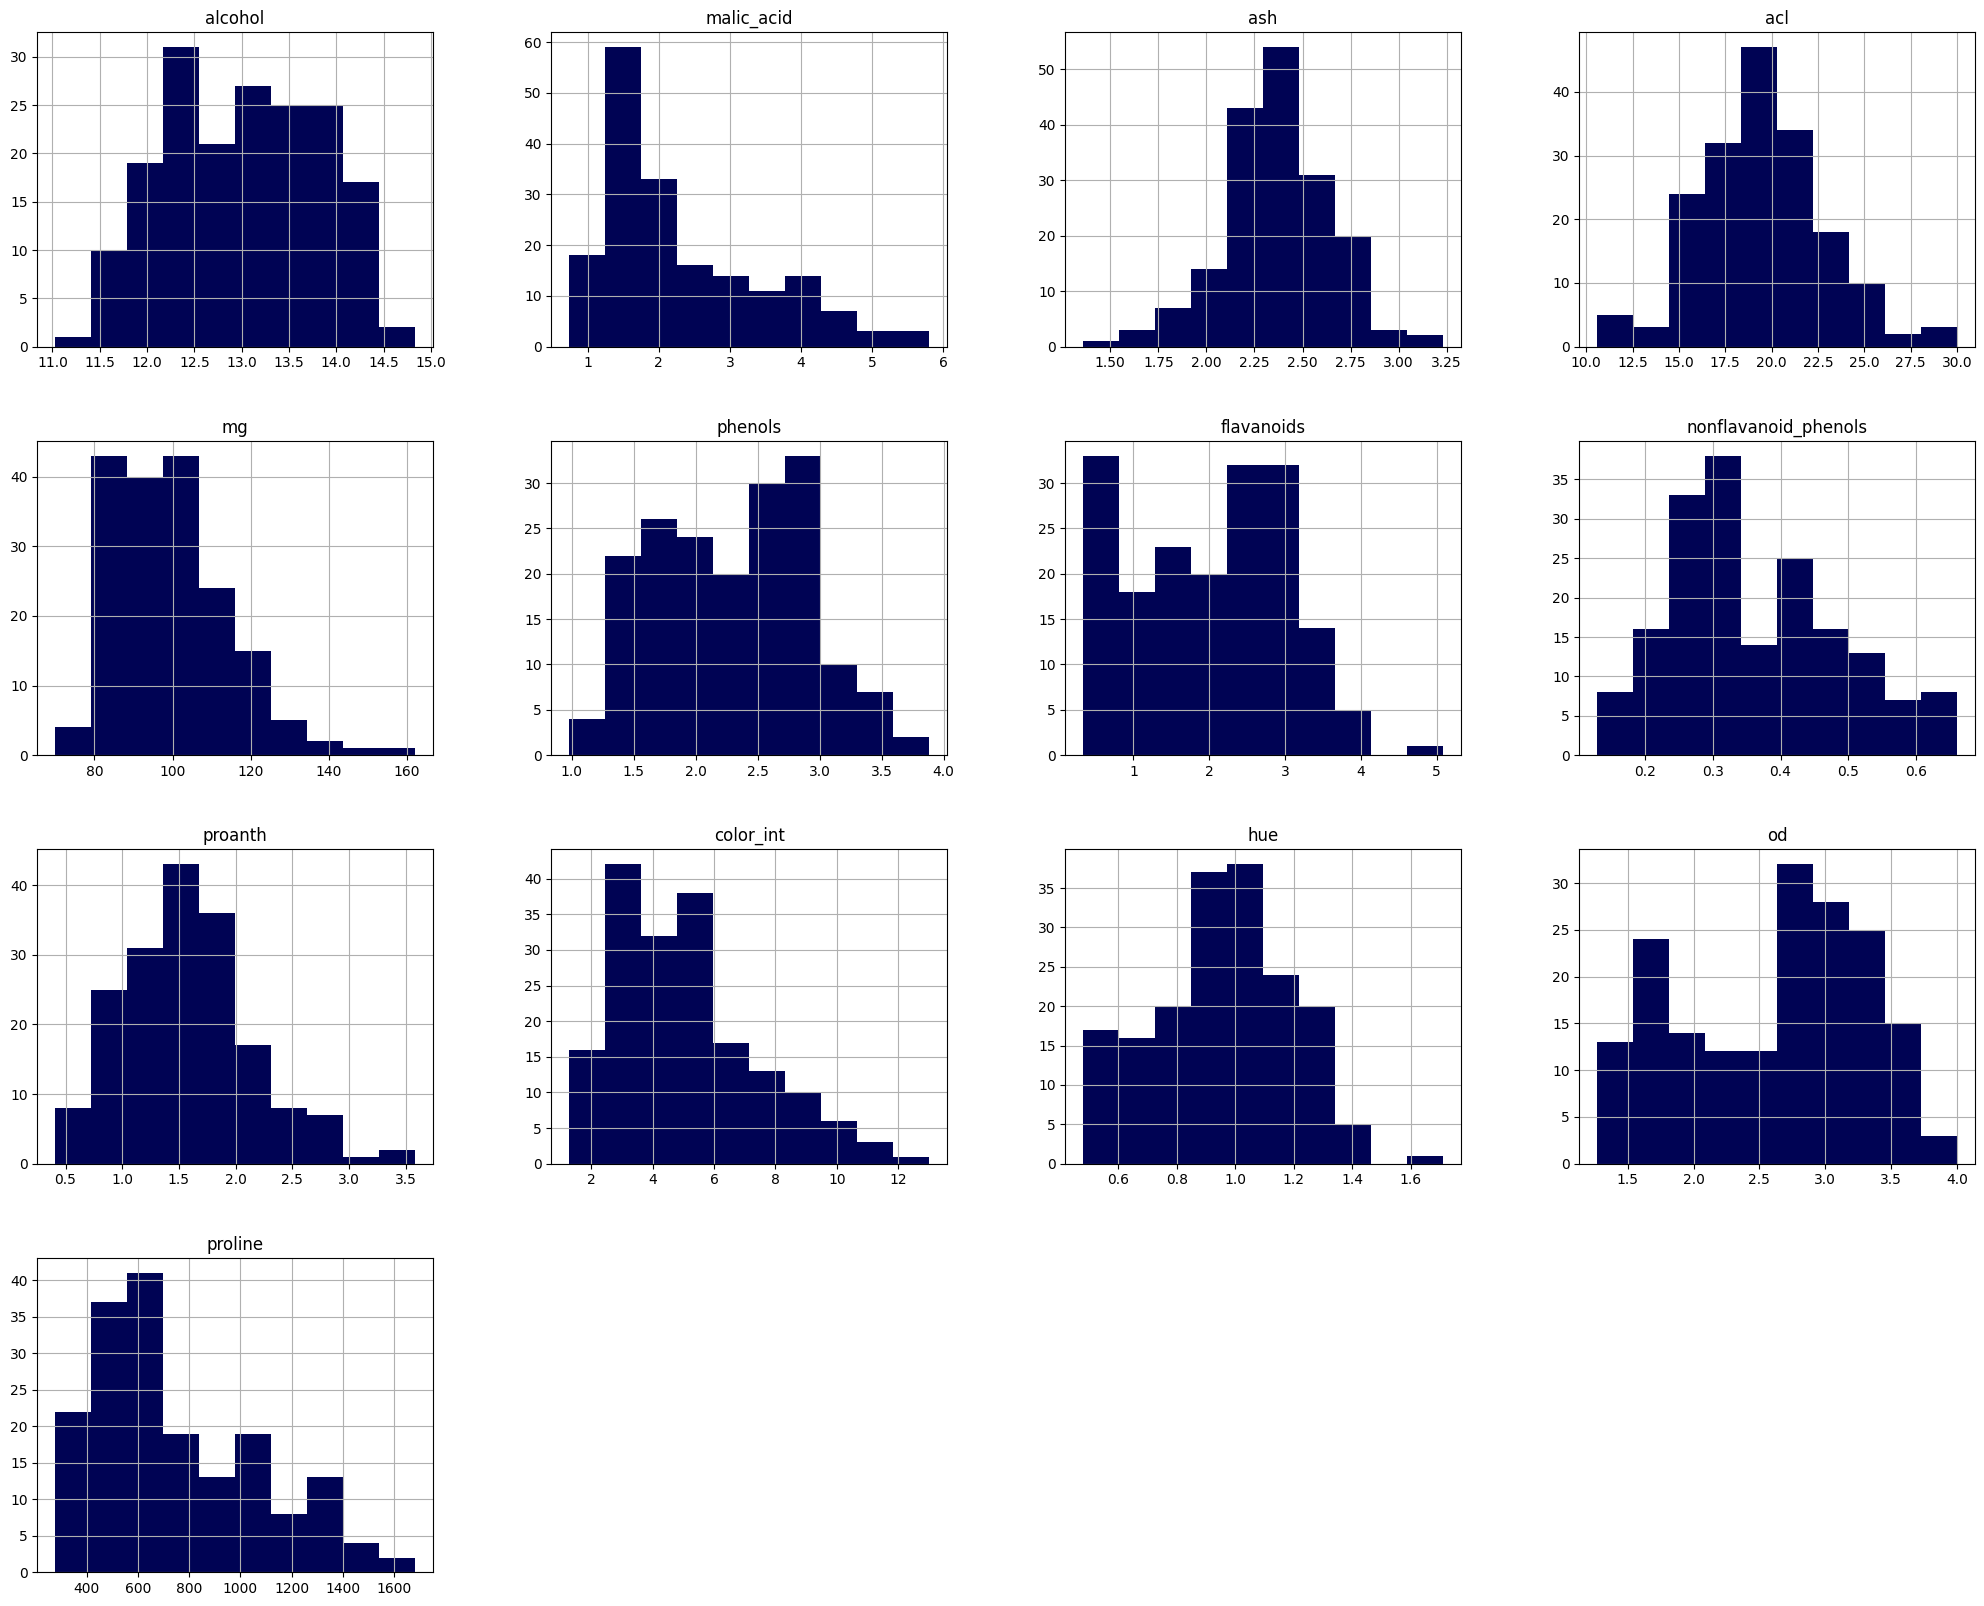

In [ ]:
# create distributions
df_1 = df.copy()
df_1 = df_1.drop('wine', axis = 1)
features = df_1.columns
df_1[features].hist(figsize = (25,20),  color = '#000354');

**Observations**:

- Alcohol: Centered around 13.2–13.5, with a smooth spread. Indicates consistent ethanol content across samples.
- Malic_acid: Slightly skewed but generally symmetric. Suggests moderate variation in acidity.
- Ash: Fairly tight distribution, implying uniform mineral content.
- Phenols and Flavanoids: Both show strong central tendencies, which is great for modeling antioxidant properties.
- Color_int and Hue: Nicely bell-shaped, indicating balanced visual characteristics across wine classes.
- OD (Optical Density): Smooth and symmetric, useful for quality estimation.

These are still usable but may benefit from transformation or scaling:
- Acl (Alcalinity of Ash): Slight right skew; some wines have unusually high buffering capacity.
- Mg (Magnesium): Slightly right-skewed; a few samples have elevated mineral levels.
- Nonflavanoid_phenols: Slight skew, but not extreme.
- Proanth: Mild tailing on the right; some wines are richer in tannins.
- Proline: Right-skewed with a long tail—some wines have very high amino acid content.

Key takeawys
• 	Standardization (z-score scaling) is appropriate for most features.
• 	Log or Box-Cox transformations may help for skewed features like Proline or Acl.
• 	No major outliers dominate the distributions, which is great for stability.
• 	Feature selection can proceed confidently—most variables carry meaningful variation.

##### skewness/kurtosis

In [78]:
df_1 = df.copy()
features = df_1.drop('wine', axis = 1)

# Calculate kurtosis for each feature
kurtosis_values = {
    'Feature': [],
    'Kurtosis': [],
    'Interpretation': [],
    'Kurtosis Value Interpretation': []
}

k_meaning = '<3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers)'

for col in features.columns:
    k = kurtosis(df_1[col], fisher=True, bias=False)
    kurtosis_values['Feature'].append(col)
    kurtosis_values['Kurtosis'].append(round(k, 3))
    kurtosis_values['Kurtosis Value Interpretation'].append(k_meaning)
    if k > 3:
        interpretation = "Heavy tails (many outliers)"
    elif k < 3:
        interpretation = "Light tails (few outliers)"
    else:
        interpretation = "Normal-like tails"
    kurtosis_values['Interpretation'].append(interpretation)

# Display the results
kurtosis_df = pd.DataFrame(kurtosis_values)
print(tabulate(kurtosis_df, headers='keys', tablefmt='grid'))



+----+----------------------+------------+----------------------------+--------------------------------------------------------------------------------------------+
|    | Feature              |   Kurtosis | Interpretation             | Kurtosis Value Interpretation                                                              |
+====+======================+============+============================+============================================================================================+
|  0 | alcohol              |     -0.852 | Light tails (few outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+----------------------+------------+----------------------------+--------------------------------------------------------------------------------------------+
|  1 | malic_acid           |      0.299 | Light tails (few outliers) | <3: Light tails (fewer outliers), ~3: Normal distribution, >3: Heavy tails (more outliers) |
+----+----

**Key Take aways**

- The class distribution is reasonably balanced.Hence no need for resampling.
- Standardisation (z-score scaling) is appropriate for most features.
- No major outliers dominate the distributions, which is great for model's stability.


# **Model Building and Testing**

###**Feature Engineering**

The target variable (Drug), cholesterol, BP, Sex are categorical. They must be converted to numeric because , most machine learning algorithms are designed to work with numerical data. Categorical variables, which represent distinct groups or categories cannot be directly processed by these algorithms in their raw text format. Label encoding converts these textual categories into numerical representations, making them compatible with the algorithms.

- Drugs - DrugY = 4 , DrugX = 3, DrugA = 2, DrugC = 1, DrugB = 0
- BP - HIGH = 2, LOW = 0 and NORMAL = 1
- Cholesterol - HIGH = 1 and NORMAL = 0
- Sex - M = 1 and F = 0

These replacements are ,motivated by representation in the data.

In [ ]:
# Encoding categorica data
df_final = df.copy()
drug_dict = {'DrugY': 4, 'drugX': 3,'drugA': 2, 'drugC': 1, 'drugB': 0}
df_final['Drug'] = df_final['Drug'].replace(drug_dict)

gender_dict = {'M': 1, 'F': 0}
df_final['Sex'] = df_final['Sex'].replace(gender_dict)

BP_dict = {'HIGH': 2, 'NORMAL': 0, 'LOW': 1}
df_final['BP'] = df_final['BP'].replace(BP_dict)

Chol_dict = {'HIGH': 1, 'NORMAL': 0}
df_final['Cholesterol'] = df_final['Cholesterol'].replace(Chol_dict)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


###**Correlation**

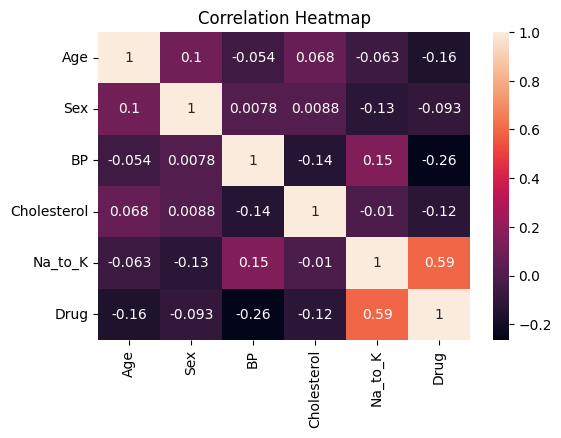

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_final.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

- There's a strong correlation between Drug and BP, as well as with Sodium to Potassium Ratio.

it prevents features with larger numerical values from disproportionately influencing the model's learning.
When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger.

In [ ]:
#scaling Age and Na_to_K
#Numeric_Columns = ['Age', 'Na_to_K']
#Scaler = MinMaxScaler()
#df_final[Numeric_Columns] = Scaler.fit_transform(df_final[Numeric_Columns])

In [ ]:
# splitting data
X = df_final.drop(columns='Drug')
Y = df_final['Drug']

# 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
# initialise model
dt = DecisionTreeClassifier()

#train model
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Making predictions
y_pred_tr = dt.predict(x_train)
y_pred_te = dt.predict(x_test)

# **Model Evaluation**

**Classification Evaluation Metrics**

In [ ]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Accuracy', 'Recall','Precision'],
    'Training': [accuracy_score(y_train, y_pred_tr), precision_score(y_train, y_pred_tr, average = 'weighted'),recall_score(y_train, y_pred_tr,average = 'weighted')],
    'Testing data': [accuracy_score(y_test, y_pred_te),precision_score(y_test, y_pred_te,average = 'weighted'),recall_score(y_test, y_pred_te,average = 'weighted')
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-----------+----------+--------------+
|   |  Metric   | Training | Testing data |
+---+-----------+----------+--------------+
| 0 | Accuracy  |   1.0    |     1.0      |
| 1 |  Recall   |   1.0    |     1.0      |
| 2 | Precision |   1.0    |     1.0      |
+---+-----------+----------+--------------+
